# Trực quan hóa dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np
conn = sqlite3.connect("../data/database/drug-food-interaction.db")




In [3]:
#Load data từ sql
df = pd.read_sql("""
    SELECT * FROM Interactions
""",conn)

df.head()

,interaction_id,drug_id,food_id,severity,description,source
0,1,1,1,Moderate,Administration with food may increase the abso...,"Cerner Multum, Inc. ""UK Summary of Product Cha..."
1,2,1,2,Moderate,Administration with food may increase the abso...,"Cerner Multum, Inc. ""UK Summary of Product Cha..."
2,3,1,3,Moderate,Administration with food may increase the abso...,"Cerner Multum, Inc. ""UK Summary of Product Cha..."
3,4,1,4,Moderate,Administration with food may increase the abso...,"Cerner Multum, Inc. ""UK Summary of Product Cha..."
4,5,2,5,High,Food significantly increases the oral bioavail...,"""Product Information. Gavreto (pralsetinib)."" ..."


## Các biểu đồ

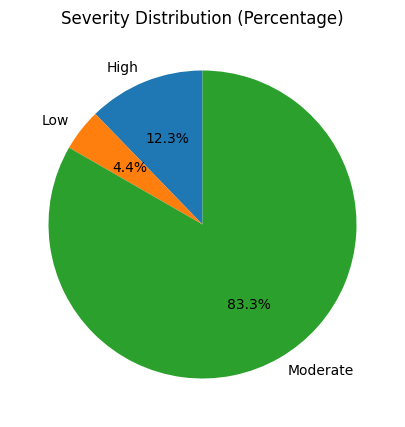

In [3]:
# chart 1: SEVERITY DISTRIBUTION
df_severity = pd.read_sql("""
SELECT severity, COUNT(*) as count
FROM Interactions
GROUP BY severity

""",conn)

plt.figure(figsize=(10,5))

plt.pie(
    df_severity["count"],
    labels=df_severity["severity"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Severity Distribution (Percentage)")
plt.show()

df_severity.to_csv("../output/severity_distribution.csv",index=False)

Biểu đồ cho thấy mức độ Moderate chiếm tỷ lệ lớn nhất,
trong khi High và Low chiếm tỷ lệ nhỏ hơn.
Điều này phản ánh phần lớn dữ liệu tương tác ở mức trung bình.

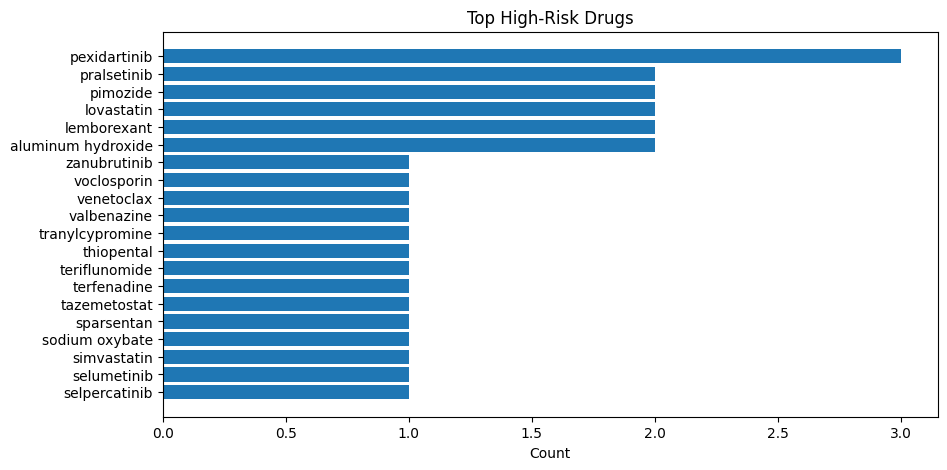

In [2]:
# Chart 2: TOP DRUGS → HORIZONTAL BAR
df_drugs = pd.read_sql("""
SELECT d.drug_name, COUNT(*) as count
FROM Interactions i
JOIN Drugs d ON i.drug_id = d.drug_id
WHERE i.severity = 'High'
GROUP BY d.drug_name
ORDER BY count DESC
LIMIT 20
""", conn)

plt.figure(figsize=(10,5))

plt.barh(df_drugs["drug_name"], df_drugs["count"])

plt.title("Top High-Risk Drugs")
plt.xlabel("Count")

plt.gca().invert_yaxis()
plt.show()

df_drugs.to_csv("../output/top_high_risk_drugs.csv",index=False)

Một số thuốc xuất hiện nhiều trong các tương tác mức High,
cho thấy nguy cơ cao khi sử dụng cùng thực phẩm.

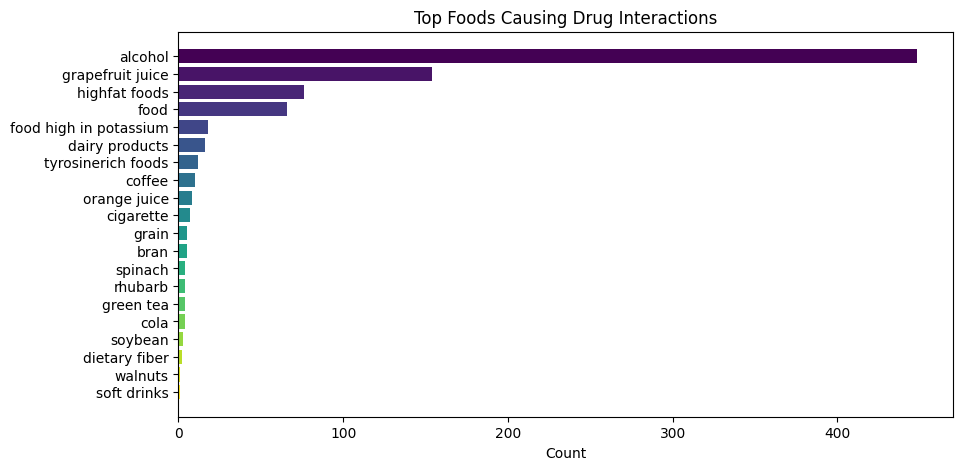

In [3]:
#chart 3: TOP FOODS → HORIZONTAL BAR
df_foods = pd.read_sql("""
SELECT f.food_name, COUNT(*) as count
FROM Interactions i
JOIN Foods f ON i.food_id = f.food_id
GROUP BY f.food_name
ORDER BY count DESC
LIMIT 20
""", conn)

colors = plt.cm.viridis(np.linspace(0, 1, len(df_foods)))

plt.figure(figsize=(10,5))

plt.barh(df_foods["food_name"], df_foods["count"], color=colors)

plt.title("Top Foods Causing Drug Interactions")
plt.xlabel("Count")

plt.gca().invert_yaxis()
plt.show()

df_foods.to_csv("../output/top_foods.csv", index=False)